## Phase 6 - Deployment Validation (API)

### Why we validate using “realistic mileage” rows
Our Phase 6 demo uses the deployed pipeline (Streamlit → FastAPI → trained model) and we want the validation to reflect **typical used-car listings**.

So, for this deployment check we:
- **Use real rows** from our dataset
- **Exclude the imputed mileage value (~31,146.90)** because it appears when missing mileage was filled, and repeating that same value can make evaluation less representative.

This gives a fair “real-world” check of the deployed API behavior using realistic vehicles.

### What the results mean
We report:
- **MAE**: average dollar error
- **RMSE**: penalizes larger mistakes more than MAE
- **MAPE**: average percent error (easy to explain as “typical % error”)
- **Accuracy within bands**: how many predictions fall within ±5%, ±10%, ±$1000, etc.

Then we also show **10–20 sample vehicles** (Actual vs Predicted) to make the results easier to interpret.


#### 20000-row API validation (realistic mileage + exclude mean-filled)

In [1]:
import json
import requests
import numpy as np
import pandas as pd
import random
from typing import Any, Optional, Dict, List, Tuple

API_BASE = "http://127.0.0.1:8000"
CSV_PATH = "encoded_dataset.csv"
MAPPINGS_PATH = "mappings.json"

N_TEST = 20000
RANDOM_STATE = 42

EXCLUDE_MILEAGE_VALUE = 31146.901467040527
EXCLUDE_TOL = 1.0

CHUNKSIZE = 200000

def to_py_float(x: Any) -> Optional[float]:
    if x is None:
        return None
    try:
        if hasattr(x, "item"):
            x = x.item()
        x = float(x)
        if np.isnan(x) or np.isinf(x):
            return None
        return x
    except Exception:
        return None

def to_py_int(x: Any) -> Optional[int]:
    if x is None:
        return None
    try:
        if hasattr(x, "item"):
            x = x.item()
        return int(float(x))
    except Exception:
        return None

with open(MAPPINGS_PATH, "r", encoding="utf-8") as f:
    m: Dict[str, Dict[str, int]] = json.load(f)

inv = {
    col: {int(v): k for k, v in m[col].items()}
    for col in ["fuel_type", "transmission", "body_type", "engine_type", "wheel_system"]
}

def series_to_payload(s: pd.Series) -> Optional[dict]:
    ft_code = to_py_int(s["fuel_type"])
    tr_code = to_py_int(s["transmission"])
    bt_code = to_py_int(s["body_type"])
    en_code = to_py_int(s["engine_type"])
    ws_code = to_py_int(s["wheel_system"])
    hi_code = to_py_int(s["has_incidents"])

    if ft_code not in inv["fuel_type"]:
        return None
    if tr_code not in inv["transmission"]:
        return None
    if bt_code not in inv["body_type"]:
        return None
    if en_code not in inv["engine_type"]:
        return None
    if ws_code not in inv["wheel_system"]:
        return None
    if hi_code not in (0, 1):
        return None

    payload = {
        "year": to_py_int(s["year"]),
        "combined_fuel_economy": to_py_float(s["combined_fuel_economy"]),
        "mileage": to_py_float(s["mileage"]),

        "fuel_type": inv["fuel_type"][ft_code],
        "transmission": inv["transmission"][tr_code],
        "body_type": inv["body_type"][bt_code],
        "engine_type": inv["engine_type"][en_code],
        "wheel_system": inv["wheel_system"][ws_code],

        "has_incidents": int(hi_code),

        "horsepower": to_py_float(s["horsepower"]),
        "torque": to_py_float(s["torque"]),
        "legroom": to_py_float(s["legroom"]),
        "maximum_seating": to_py_int(s["maximum_seating"]),
        "size_of_vehicle": to_py_float(s["size_of_vehicle"]),
        "major_options_count": to_py_float(s["major_options_count"]),
    }

    required = [
        "year", "combined_fuel_economy", "mileage", "horsepower", "torque", "legroom",
        "maximum_seating", "size_of_vehicle", "major_options_count", "has_incidents"
    ]
    if any(payload[k] is None for k in required):
        return None

    if not (1980 <= int(payload["year"]) <= 2026):
        return None
    if not (1 <= int(payload["maximum_seating"]) <= 10):
        return None
    if float(payload["mileage"]) < 0 or float(payload["combined_fuel_economy"]) < 0:
        return None

    return payload

def api_predict(payload: dict) -> float:
    r = requests.post(f"{API_BASE}/predict", json=payload, timeout=30)
    r.raise_for_status()
    return float(r.json()["predicted_price"])

needed = [
    "price", "year", "combined_fuel_economy", "mileage", "fuel_type", "transmission", "body_type",
    "engine_type", "horsepower", "torque", "legroom", "maximum_seating", "size_of_vehicle",
    "has_incidents", "wheel_system", "major_options_count"
]

num_cols = [
    "price", "year", "combined_fuel_economy", "mileage", "horsepower", "torque", "legroom",
    "maximum_seating", "size_of_vehicle", "has_incidents", "major_options_count",
    "fuel_type", "transmission", "body_type", "engine_type", "wheel_system"
]

print(
    f"Collecting {N_TEST} valid API tests "
    f"(full mileage range, excluding ~{EXCLUDE_MILEAGE_VALUE:.2f})..."
)

rng = random.Random(RANDOM_STATE)
reservoir: List[Tuple[float, dict]] = []
valid_seen = 0

for chunk_idx, df in enumerate(pd.read_csv(CSV_PATH, chunksize=CHUNKSIZE)):
    df = df.dropna(subset=needed).copy()

    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=num_cols)

    df = df[df["price"] > 0]

    df = df[np.abs(df["mileage"] - EXCLUDE_MILEAGE_VALUE) > EXCLUDE_TOL]

    if df.empty:
        continue

    df = df.sample(frac=1, random_state=RANDOM_STATE + chunk_idx).reset_index(drop=True)

    for _, row in df.iterrows():
        payload = series_to_payload(row)
        if payload is None:
            continue

        actual = to_py_float(row["price"])
        if actual is None or actual <= 0:
            continue

        valid_seen += 1

        if len(reservoir) < N_TEST:
            reservoir.append((actual, payload))
        else:
            j = rng.randrange(valid_seen)
            if j < N_TEST:
                reservoir[j] = (actual, payload)

actuals_list: List[float] = []
preds_list: List[float] = []
payloads_list: List[dict] = []

tries = 0
for actual, payload in reservoir:
    tries += 1
    try:
        pred = api_predict(payload)
    except Exception:
        continue
    actuals_list.append(actual)
    preds_list.append(pred)
    payloads_list.append(payload)

actuals_np = np.asarray(actuals_list, dtype=float)
preds_np = np.asarray(preds_list, dtype=float)

abs_err = np.abs(preds_np - actuals_np)
pct_err = (abs_err / np.clip(actuals_np, 1e-9, None)) * 100

mae = float(abs_err.mean())
rmse = float(np.sqrt(((preds_np - actuals_np) ** 2).mean()))
mape = float(pct_err.mean())

print()
print(f"Tested rows: {len(preds_np)} (tries: {tries})")
print("=== Deployment validation metrics (API) ===")
print(f"MAE  ($): {mae:,.2f}")
print(f"RMSE ($): {rmse:,.2f}")
print(f"MAPE (%): {mape:.2f}%")

print()
print("Error percentiles")
for q in [50, 75, 90, 95]:
    print(f"{q}th abs error: ${np.percentile(abs_err, q):,.2f}")
for q in [50, 75, 90, 95]:
    print(f"{q}th pct error: {np.percentile(pct_err, q):.2f}%")

print()
print("Accuracy within % error bands")
for t in [5, 10, 15, 20]:
    count = int((pct_err <= t).sum())
    print(f"Within ±{t}%: {count}/{len(pct_err)} ({count/len(pct_err)*100:.2f}%)")

print()
print("Accuracy within $ error bands")
for d in [1000, 2000, 5000]:
    count = int((abs_err <= d).sum())
    print(f"Within ±${d}: {count}/{len(abs_err)} ({count/len(abs_err)*100:.2f}%)")



Tested rows: 20000 (tries: 20000)
=== Deployment validation metrics (API) ===
MAE  ($): 2,111.35
RMSE ($): 3,684.84
MAPE (%): 6.84%

Error percentiles
50th abs error: $1,314.81
75th abs error: $2,676.34
90th abs error: $4,702.87
95th abs error: $6,327.93
50th pct error: 4.96%
75th pct error: 9.14%
90th pct error: 14.54%
95th pct error: 18.81%

Accuracy within % error bands
Within ±5%: 10065/20000 (50.32%)
Within ±10%: 15626/20000 (78.13%)
Within ±15%: 18146/20000 (90.73%)
Within ±20%: 19140/20000 (95.70%)

Accuracy within $ error bands
Within ±$1000: 8116/20000 (40.58%)
Within ±$2000: 12995/20000 (64.98%)
Within ±$5000: 18250/20000 (91.25%)


Overall, the API prediction quality looks stable.

On average, the prediction is off by about USD 2,111 (MAE). The typical percentage error is around 6.84% (MAPE), which means the model is usually within about 7% of the true listing price. RMSE is USD 3,685, which shows there are some larger errors, but they are not happening for most cars.

Looking at the distribution, half of the cars have an error below USD 1,315 and 75% are below about USD 2,676. In percentage terms, half the cars are within 4.96% and 75% are within 9.14%. Most predictions are quite close, and only a smaller portion becomes larger mistakes.

The accuracy bands confirm this consistency: about 78% of predictions are within ±10% of the true price, about 91% are within ±15%, and about 96% are within ±20%. In dollar terms, around 65% are within ±USD 2,000 and about 91% are within ±USD 5,000.

So, as a Phase 6 deployment check, the pipeline is working well and the API gives useful price estimates for most typical used car listings.


#### Visualization

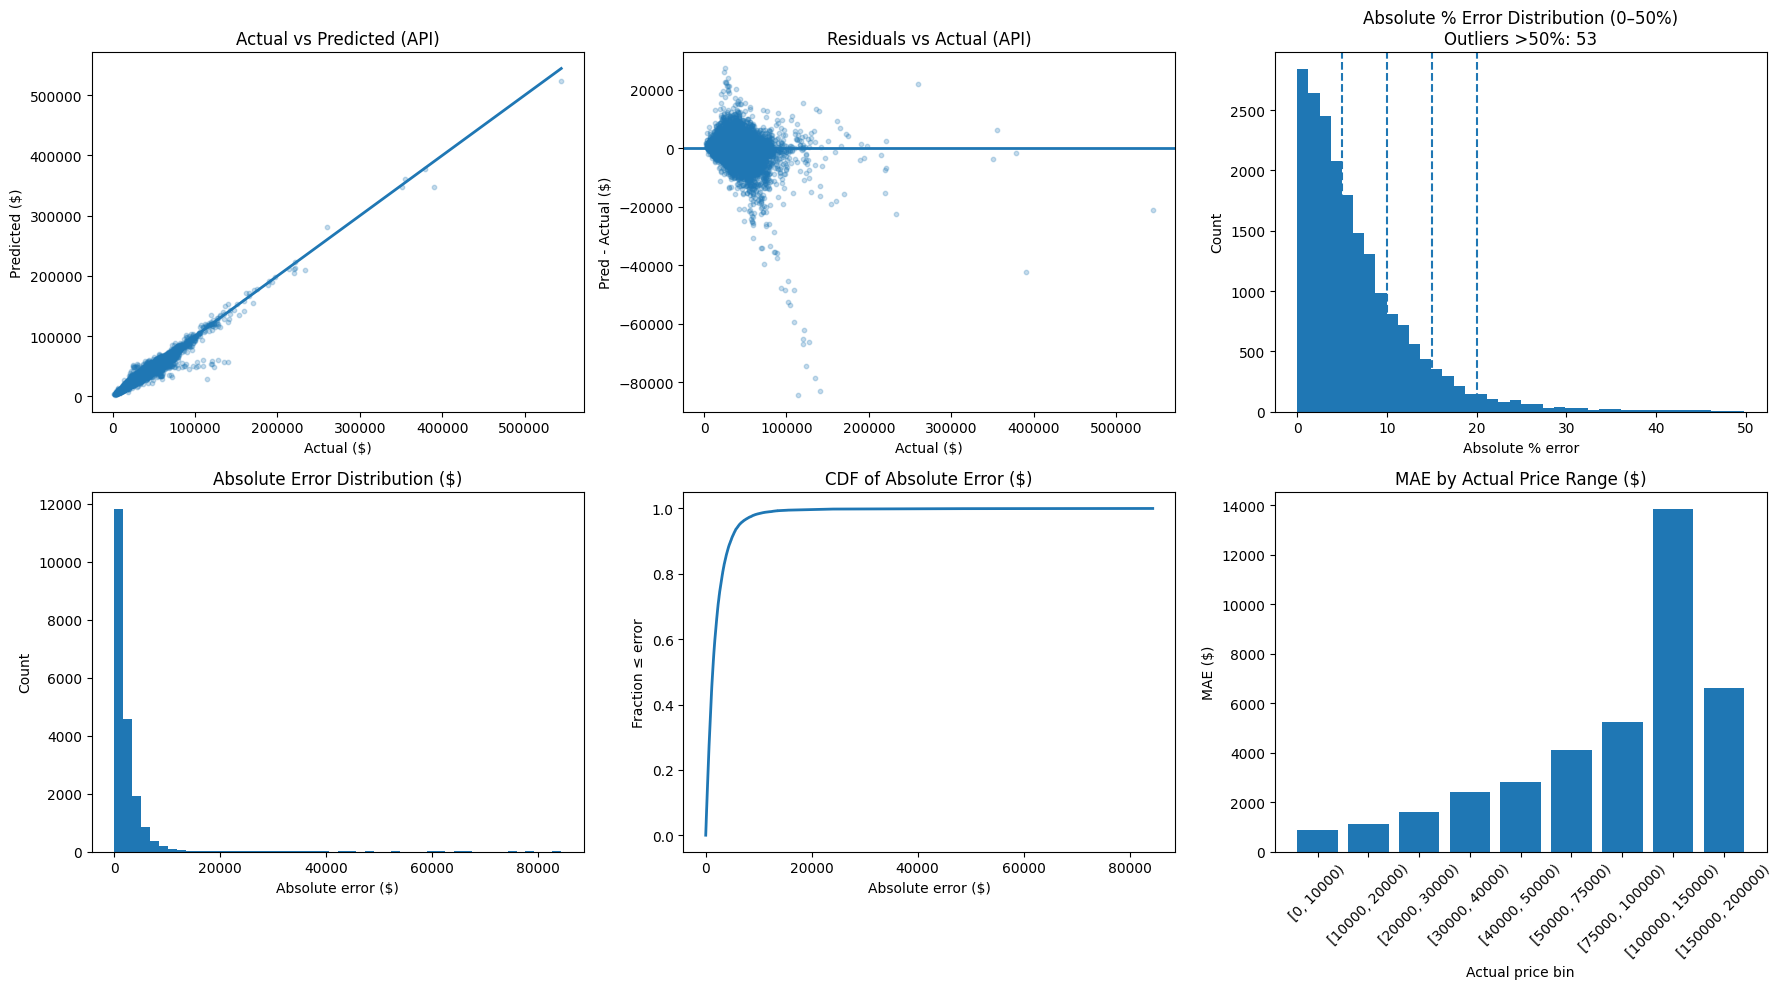

In [ ]:
import matplotlib.pyplot as plt

res = pd.DataFrame({
    "actual_price": np.asarray(actuals_np, dtype=float),
    "pred_price":   np.asarray(preds_np, dtype=float),
})

res = res.replace([np.inf, -np.inf], np.nan).dropna()
res = res[res["actual_price"] > 0].copy()

res["residual"] = res["pred_price"] - res["actual_price"]
res["abs_error"] = res["residual"].abs()
res["pct_error_%"] = (res["abs_error"] / res["actual_price"]) * 100

ZOOM_MAX_PCT = 50
pct = res["pct_error_%"].to_numpy()
pct_zoom = pct[pct <= ZOOM_MAX_PCT]
pct_outliers = int((pct > ZOOM_MAX_PCT).sum())

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

# Actual vs Predicted
ax[0,0].scatter(res["actual_price"], res["pred_price"], alpha=0.25, s=10)
minv = min(res["actual_price"].min(), res["pred_price"].min())
maxv = max(res["actual_price"].max(), res["pred_price"].max())
ax[0,0].plot([minv, maxv], [minv, maxv], linewidth=2)
ax[0,0].set_title("Actual vs Predicted (API)")
ax[0,0].set_xlabel("Actual ($)")
ax[0,0].set_ylabel("Predicted ($)")
ax[0,0].ticklabel_format(style="plain", axis="both")

# Residuals vs Actual
ax[0,1].scatter(res["actual_price"], res["residual"], alpha=0.25, s=10)
ax[0,1].axhline(0, linewidth=2)
ax[0,1].set_title("Residuals vs Actual (API)")
ax[0,1].set_xlabel("Actual ($)")
ax[0,1].set_ylabel("Pred - Actual ($)")
ax[0,1].ticklabel_format(style="plain", axis="both")

# Absolute % Error Distribution
ax[0,2].hist(pct_zoom, bins=40)
for v in [5, 10, 15, 20]:
    ax[0,2].axvline(v, linestyle="--", linewidth=1.5)
ax[0,2].set_title(
    f"Absolute % Error Distribution (0–{ZOOM_MAX_PCT}%)\nOutliers >{ZOOM_MAX_PCT}%: {pct_outliers}"
)
ax[0,2].set_xlabel("Absolute % error")
ax[0,2].set_ylabel("Count")

# Absolute Error Distribution
ax[1,0].hist(res["abs_error"], bins=50)
ax[1,0].set_title("Absolute Error Distribution ($)")
ax[1,0].set_xlabel("Absolute error ($)")
ax[1,0].set_ylabel("Count")
ax[1,0].ticklabel_format(style="plain", axis="x")

# CDF of Absolute Error
abs_sorted = np.sort(res["abs_error"].to_numpy())
cdf = np.arange(1, len(abs_sorted) + 1) / len(abs_sorted)
ax[1,1].plot(abs_sorted, cdf, linewidth=2)
ax[1,1].set_title("CDF of Absolute Error ($)")
ax[1,1].set_xlabel("Absolute error ($)")
ax[1,1].set_ylabel("Fraction ≤ error")
ax[1,1].ticklabel_format(style="plain", axis="x")

# MAE by Actual Price Range
bins = [0, 10000, 20000, 30000, 40000, 50000, 75000, 100000, 150000, 200000]
res["price_bin"] = pd.cut(res["actual_price"], bins=bins, right=False)
mae_by_bin = res.groupby("price_bin", observed=True)["abs_error"].mean()

ax[1,2].bar([str(b) for b in mae_by_bin.index], mae_by_bin.values)
ax[1,2].set_title("MAE by Actual Price Range ($)")
ax[1,2].set_xlabel("Actual price bin")
ax[1,2].set_ylabel("MAE ($)")
ax[1,2].ticklabel_format(style="plain", axis="y")
ax[1,2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Deployment validation indicates strong real-world performance: predictions are well-calibrated and residuals are centered near zero. Most API predictions have low percentage error, while a small number of outliers create a long tail. Error levels increase for higher priced vehicles, so the API is most reliable for typical market cars and should be used with more caution for luxury or rare listings

#### Show 10 - 20 “Actual vs Predicted” samples in table (For just test)

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display

SAMPLE_SHOW = 20

res_s = pd.DataFrame({
    "actual_price": np.asarray(actuals_np[:SAMPLE_SHOW], dtype=float),
    "pred_price":   np.asarray(preds_np[:SAMPLE_SHOW], dtype=float),
})

res_s["abs_error"] = np.abs(res_s["pred_price"] - res_s["actual_price"])
res_s["pct_error_%"] = (res_s["abs_error"] / np.clip(res_s["actual_price"], 1e-9, None)) * 100

res_sorted = res_s.sort_values("pct_error_%", ascending=False).reset_index(drop=True)

res_display = res_sorted.copy()
res_display["actual_price"] = res_display["actual_price"].map(lambda x: f"${x:,.0f}")
res_display["pred_price"]  = res_display["pred_price"].map(lambda x: f"${x:,.0f}")
res_display["abs_error"]   = res_display["abs_error"].map(lambda x: f"${x:,.0f}")
res_display["pct_error_%"] = res_display["pct_error_%"].map(lambda x: f"{x:.2f}%")

print(f"Showing {SAMPLE_SHOW} examples (sorted by highest % error first):")
display(res_display)

abs_err_s = np.abs(preds_np[:SAMPLE_SHOW] - actuals_np[:SAMPLE_SHOW])
pct_err_s = (abs_err_s / np.clip(actuals_np[:SAMPLE_SHOW], 1e-9, None)) * 100

print(f"Samples: {SAMPLE_SHOW}")
print(f"MAE ($): {abs_err_s.mean():,.2f}")
print(f"MAPE (%): {pct_err_s.mean():.2f}%")
print(f"Within ±10%: {(pct_err_s <= 10).mean()*100:.2f}%")


Showing 20 examples (sorted by highest % error first):


,actual_price,pred_price,abs_error,pct_error_%
0,"$17,216","$20,916","$3,700",21.49%
1,"$36,962","$30,267","$6,695",18.11%
2,"$14,595","$16,390","$1,795",12.30%
3,"$22,695","$25,409","$2,714",11.96%
4,"$35,161","$39,180","$4,019",11.43%
5,"$33,995","$37,613","$3,618",10.64%
6,"$14,151","$15,657","$1,506",10.64%
7,"$48,985","$44,023","$4,962",10.13%
8,"$43,940","$47,771","$3,831",8.72%
9,"$14,992","$13,761","$1,231",8.21%


Samples: 20
MAE ($): 2,143.49
MAPE (%): 7.13%
Within ±10%: 60.00%


In these 20 random vehicles, the model is mostly close, but there are a few clear misses. The average error is about USD 2.1k (MAE), and the typical percent error is around 7.1% (MAPE).

60% of the cars are within ±10%, which is okay, but not as strong as our larger 20,000-row API validation. The biggest errors here come from a few cars with about 18–21% difference, which pulls the average up.
